# Tier 17: battery equivalent circuit with sag and ageing

Until this tier the battery had a constant open-circuit voltage (800 V) and a
tiny resistance, so its terminal voltage was nearly a straight line in
current and flat in SOC. That is the "weird, linear" curve on the dashboard.
This tier adds `EquivalentCircuitBattery`, a distinct component. The
constant `Battery` remains the simplest model and is still the Halo
reference.

**Source data.** S. Paudel, J. Zhang, B. Ayalew, R. Singh, "Systematic
Characterization of Lithium-Ion Cells for Electric Mobility and Grid Storage:
A Case Study on Samsung INR21700-50G", *Batteries* 2025, 11, 313 (CC BY 4.0,
https://doi.org/10.3390/batteries11080313), user-supplied.

| Figure | Content | Digitized as |
|---|---|---|
| Fig. 7 (raster) | OCV at 5 % SOC steps, -10 to 45 C | colour clusters per marker column, about +-5 mV at 30/45 C |
| Fig. 8 (vector) | DCIR and pulse power, 2/10/30/180 s pulses, SOC 0.2-0.8, six temperatures | exact curve vertices with PyMuPDF `get_drawings()`, 1,232 points |
| Fig. 12 (raster) | 2-RC ECM parameters | colour clusters; reference only (time constants) |
| Table 1 | 4.9 Ah, 69 g, 3.6 V nominal, 2.5-4.2 V, 9.8 A continuous | as printed |

The files are in `data/batteries/`; each header records the method and the
accuracy.

**Model** (`powertrain/components/battery_ecm.py`):

- **OCV:** OCV(SOC) is a degree-7 polynomial through the 30 C data. The
  B-spline table remains available as an option.
- **Resistance:** R0 plus two RC branches (tau 8 s and 43 s, from Fig. 12).
  R(SOC, T) is a smooth fit to all 308 discharge DCIR points.
- **Pack:** `count_series` x `count_parallel` cells. The cell-to-pack mass
  ratio is 0.7 (assumed).
- **Ageing:** end-of-life capacity 0.8 and resistance 1.5 (assumed).

**User decision (2026-10-02).** The resistance is divided by an explicit,
named power-density factor F, and the current rating is multiplied by it.
The shape of the discharge behaviour stays that of the 50G.

**Algebraic loop.**

- **Equations:** V = V* - I R_eff and P = V I are equalities in the caller's
  Opti. Battery current is already a variable, so nothing iterates.
- **Branch constraint:** V >= V*/2 selects the physical, low-current root
  of R_eff I^2 - V* I + P = 0.

```powershell
uv run jupyter lab notebooks/tier17_battery
```

In [1]:
import sys
from dataclasses import replace
from pathlib import Path

repo_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import aerosandbox.tools.units as u
import matplotlib.pyplot as plt

from aircraft_closure.powertrain import cells
from aircraft_closure.powertrain.components.battery import Battery
from aircraft_closure.powertrain.components.battery_ecm import EquivalentCircuitBattery, inr21700_50g_cell
from functools import partial

from examples.halo_sizing import (HaloAssumptions, assumptions_tier12b, requirements_tier12b, soc_emergency_floor,
                                  soc_minimum)
from examples.halo_sizing import solve_halo_sizing as solve_current

# Pinned to the aircraft this tier was sized on: Tier 12b specific-power machines, no hot-day hover. The current
# reference (Tier 13 machines) gives 785 kg with the same pack; see tests/integration/test_halo_battery_ecm.py.
assumptions_tier17 = replace(assumptions_tier12b, battery_model="ecm")
solve_halo_sizing = partial(solve_current, requirements=requirements_tier12b, assumptions=assumptions_tier12b)

check_log = []


def check(name, passed):
    """Record and print one named verification."""
    passed = bool(passed)
    check_log.append((name, passed))
    print(("PASS  " if passed else "FAIL  ") + name)


ink, ink_muted, grid_color = "#1a1a19", "#5e5d58", "#e4e3dc"
blue, orange, aqua, yellow = "#2a78d6", "#eb6834", "#1baf7a", "#eda100"
ramp = ["#0d366b", "#184f95", "#256abf", "#3987e5", "#6da7ec", "#9ec5f4"]   # ordinal (blue 700 -> 200)
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": grid_color, "grid.linewidth": 0.8,
                     "axes.labelcolor": ink, "xtick.color": ink_muted, "ytick.color": ink_muted})
cell = inr21700_50g_cell()
ocv_table, dcir_table = cells.load_ocv_table(), cells.load_dcir_table()

## 1. Open-circuit voltage: digitized data and fit

The cell model's OCV is the 30 C curve. That temperature has the complete
0–1 range and the largest markers. The model has no OCV temperature term.
Fig. 7 shows that above 30 % SOC the curves for 10–45 C differ by only a few
tens of mV. Only the -10 C curve departs at low SOC, and the paper's own
-10 C test stops at 15 % SOC.

degree-7 polynomial vs 30 C data: rms 9.2 mV, max 20.7 mV (digitization about +-5 mV)
PASS  OCV fit within 25 mV of every 30 C point
PASS  OCV fit is monotonic in SOC
PASS  tabulated OCV recovers its nodes
PASS  reference point: OCV(50 %, 30 C) = 3.72 V +- 0.02
cell energy 4.9 Ah x mean OCV 3.704 V = 18.15 Wh (263 Wh/kg cell)


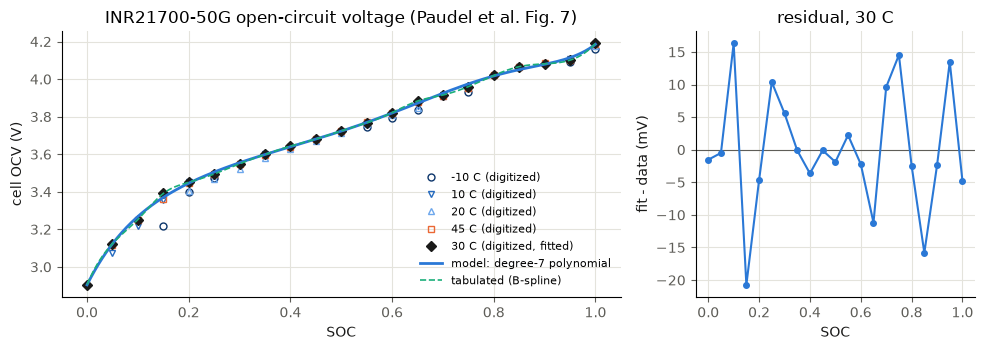

In [2]:
soc30, ocv30 = ocv_table.at_temperature(30.0)
grid = np.linspace(0, 1, 401)
tabulated = cells.tabulated_ocv_model(30.0)
residual_V = cell.ocv_model.voltage_V(soc30) - ocv30
print(f"degree-7 polynomial vs 30 C data: rms {1e3 * np.sqrt(np.mean(residual_V**2)):.1f} mV, "
      f"max {1e3 * np.max(np.abs(residual_V)):.1f} mV (digitization about +-5 mV)")
check("OCV fit within 25 mV of every 30 C point", np.max(np.abs(residual_V)) < 0.025)
check("OCV fit is monotonic in SOC", np.all(np.diff(cell.ocv_model.voltage_V(grid)) > 0))
check("tabulated OCV recovers its nodes", np.allclose(tabulated.voltage_V(soc30), ocv30, atol=1e-9))
check("reference point: OCV(50 %, 30 C) = 3.72 V +- 0.02", abs(ocv30[10] - 3.72) < 0.02)
print(f"cell energy 4.9 Ah x mean OCV {cell.ocv_model.mean_voltage_V():.3f} V = "
      f"{cell.capacity_As * cell.ocv_model.mean_voltage_V() / 3600:.2f} Wh "
      f"({cell.capacity_As * cell.ocv_model.mean_voltage_V() / 3600 / cell.mass_kg:.0f} Wh/kg cell)")

fig, (ax, ax_r) = plt.subplots(1, 2, figsize=(10, 3.6), gridspec_kw=dict(width_ratios=[2, 1]))
for (temperature_C, color, marker) in zip((-10, 10, 20, 45), (ramp[0], ramp[2], ramp[4], orange), "ov^s"):
    s, v = ocv_table.at_temperature(float(temperature_C))
    ax.plot(s, v, marker, color=color, markersize=5, markerfacecolor="none", label=f"{temperature_C} C (digitized)")
ax.plot(soc30, ocv30, "D", color=ink, markersize=5, label="30 C (digitized, fitted)")
ax.plot(grid, cell.ocv_model.voltage_V(grid), color=blue, lw=2, label="model: degree-7 polynomial")
ax.plot(grid, tabulated.voltage_V(grid), color=aqua, lw=1.2, ls="--", label="tabulated (B-spline)")
ax.set(xlabel="SOC", ylabel="cell OCV (V)", title="INR21700-50G open-circuit voltage (Paudel et al. Fig. 7)")
ax.legend(frameon=False, fontsize=8, loc="lower right")
ax_r.axhline(0, color=ink_muted, lw=0.8)
ax_r.plot(soc30, 1e3 * residual_V, "o-", color=blue, markersize=4)
ax_r.set(xlabel="SOC", ylabel="fit - data (mV)", title="residual, 30 C")
fig.tight_layout()

## 2. Resistance: DCIR data (vector) and the 2-RC fit

- **What DCIR measures:** DCIR = delta V / I at the end of a pulse from
  rest. That includes the OCV drift while the pulse discharges the cell:
  dOCV/dSOC x t / Q. The drift doesn't depend on the current, and it is
  removed before fitting.
- **Model:** the model's pulse response is
  R0 + R1 (1 - e^(-t/8 s)) + R2 (1 - e^(-t/43 s)), with
  R_k(SOC, T) = R_k,ref exp(a x + b x^2) (1 + c e^(-(s-0.2)/w_lo) + d e^((s-0.8)/w_hi))
  and x = T_ref/T - 1.
- **Fit:** an `asb.Opti` least squares over all 308 discharge points
  (`cells.fit_resistance_model`).
- **Cross-check:** the paper's power formula,
  P = 2.5 V (OCV - 2.5 V) / DCIR, reproduces the separately digitized Fig. 8
  power curves. That validates both digitizations.

2-RC fit vs 308 discharge DCIR points: rms 4.7 %, max 20.6 %
   -10 C: rms  5.1 %
     0 C: rms  4.1 %
    10 C: rms  3.4 %
    20 C: rms  7.0 %
    30 C: rms  4.0 %
    45 C: rms  3.7 %
PASS  resistance fit rms below 5 % over all temperatures and pulses


C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


PASS  the Opti refit reproduces the coded coefficients
P = 2.5 (OCV - 2.5) / DCIR vs digitized Fig. 8 power (20-45 C): rms 1.3 %
PASS  the two digitizations agree (pulse power within 1.5 % rms)


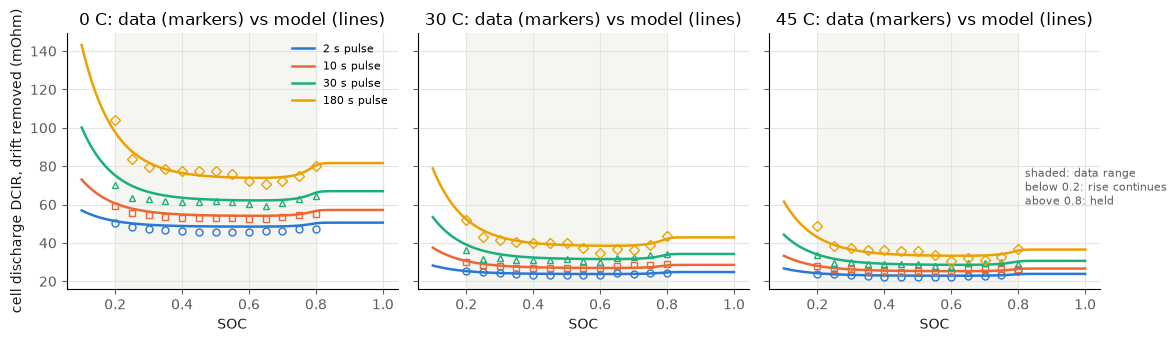

In [3]:
discharge = dcir_table.select(True)
target_ohm = cells.resistance_dc_corrected_ohm(discharge, cell.ocv_model, cell.capacity_As)
model_ohm = cell.resistance_model.resistance_dc_ohm(discharge.soc, discharge.temperature_C, discharge.duration_pulse_s)
relative = model_ohm / target_ohm - 1
print(f"2-RC fit vs 308 discharge DCIR points: rms {100 * np.sqrt(np.mean(relative**2)):.1f} %, "
      f"max {100 * np.max(np.abs(relative)):.1f} %")
for temperature_C in (-10, 0, 10, 20, 30, 45):
    mask = discharge.temperature_C == temperature_C
    print(f"  {temperature_C:4d} C: rms {100 * np.sqrt(np.mean(relative[mask]**2)):4.1f} %")
check("resistance fit rms below 5 % over all temperatures and pulses", np.sqrt(np.mean(relative**2)) < 0.05)
refit, _ = cells.fit_resistance_model()
check("the Opti refit reproduces the coded coefficients",
      all(abs(a.resistance_ref_ohm / b.resistance_ref_ohm - 1) < 1e-3
          for a, b in zip(refit.branches, cell.resistance_model.branches)))
mask = discharge.temperature_C >= 20
power_W = cells.pulse_power_W(cell.ocv_model.voltage_V(discharge.soc[mask]), discharge.resistance_dc_ohm[mask])
power_error = power_W / discharge.power_pulse_W[mask] - 1
print(f"P = 2.5 (OCV - 2.5) / DCIR vs digitized Fig. 8 power (20-45 C): rms {100 * np.sqrt(np.mean(power_error**2)):.1f} %")
check("the two digitizations agree (pulse power within 1.5 % rms)", np.sqrt(np.mean(power_error**2)) < 0.015)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
soc_line = np.linspace(0.1, 1.0, 181)
for ax, temperature_C in zip(axes, (0, 25, 45)):
    data_T = 30 if temperature_C == 25 else temperature_C
    for duration_s, color, marker in zip((2, 10, 30, 180), (blue, orange, aqua, yellow), "os^D"):
        m = (discharge.temperature_C == data_T) & (discharge.duration_pulse_s == duration_s)
        ax.plot(discharge.soc[m], 1e3 * target_ohm[m], marker, color=color, markersize=5, markerfacecolor="none")
        ax.plot(soc_line, 1e3 * cell.resistance_model.resistance_dc_ohm(soc_line, float(data_T), float(duration_s)),
                color=color, lw=1.8, label=f"{duration_s} s pulse")
    ax.axvspan(0.2, 0.8, color=grid_color, alpha=0.35, lw=0)
    ax.set(xlabel="SOC", title=f"{data_T} C: data (markers) vs model (lines)")
axes[0].set_ylabel("cell discharge DCIR, drift removed (mOhm)")
axes[0].legend(frameon=False, fontsize=8)
axes[2].annotate("shaded: data range\nbelow 0.2: rise continues\nabove 0.8: held", xy=(0.82, 60), fontsize=8, color=ink_muted)
fig.tight_layout()

## 3. The discharge-curve shape the old model missed

Here is one 50G cell scaled by F = 5 at 25 C, at end of life (capacity 0.8,
resistance 1.5). That is the cell in the Halo option below.

- **Left panel:** terminal voltage against discharge power at five SOCs.
  - Each curve is the low-current root of R I^2 - V* I + P = 0 (solid) up
    to P_max = V*^2 / 4R. Past that point the dotted high-current root is
    the branch the constraint V >= V*/2 excludes.
  - The 2.5 V cutoff line marks the usable power at each SOC.
- **Right panel:** a constant-power discharge against SOC.
  - The new model shows the real knee below 20 % SOC.
  - The old constant-OCV `Battery`, scaled to one cell, is a flat line.

C:\Users\alexa\AppData\Local\Temp\ipykernel_47980\3483563384.py:27: RuntimeWarning: invalid value encountered in sqrt
  current = (v_star - np.sqrt(v_star**2 - 4 * r * power_cell_W)) / (2 * r)


PASS  P_max = V*^2 / 4R is the peak of V I (numerically)
PASS  terminal voltage falls with SOC at constant power, steeply below 20 %


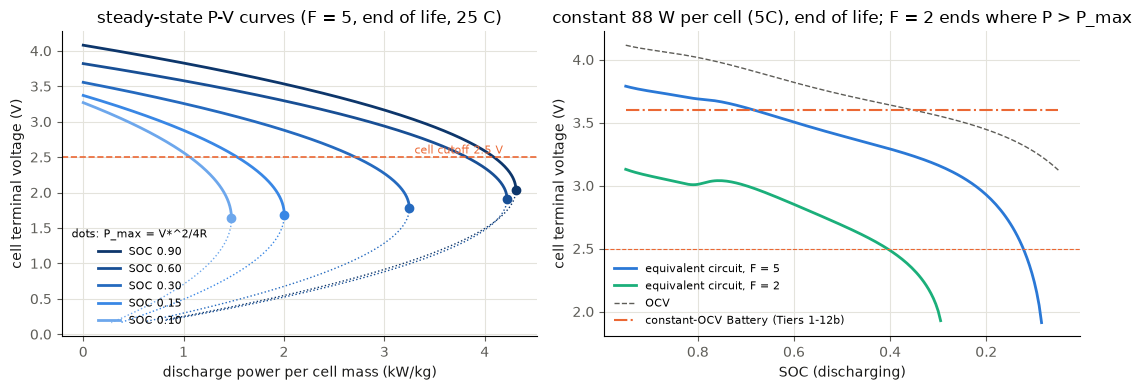

In [4]:
eol = dict(factor_power_density=5.0, factor_capacity_ageing=0.8, factor_resistance_ageing=1.5)
one = EquivalentCircuitBattery(count_series=1, count_parallel=1.0, **eol)
fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4))
for soc, color in zip((0.9, 0.6, 0.3, 0.15, 0.1), ramp[:5]):
    steady = one.evaluate(0.0, soc)
    v_star, r = float(steady.voltage_driving_V), float(steady.resistance_effective_ohm)
    current_low = np.linspace(0, v_star / (2 * r), 200)
    current_high = np.linspace(v_star / (2 * r), 0.95 * v_star / r, 100)
    ax.plot(current_low * (v_star - current_low * r) / cell.mass_kg / 1e3, v_star - current_low * r, color=color, lw=2,
            label=f"SOC {soc:.2f}")
    ax.plot(current_high * (v_star - current_high * r) / cell.mass_kg / 1e3, v_star - current_high * r, color=color,
            lw=1, ls=":")
    ax.plot(v_star**2 / (4 * r) / cell.mass_kg / 1e3, v_star / 2, "o", color=color, markersize=6)
ax.axhline(2.5, color=orange, lw=1.2, ls="--")
ax.annotate("cell cutoff 2.5 V", xy=(3.3, 2.55), color=orange, fontsize=8)
ax.set(xlabel="discharge power per cell mass (kW/kg)", ylabel="cell terminal voltage (V)",
       title="steady-state P-V curves (F = 5, end of life, 25 C)")
ax.legend(frameon=False, fontsize=8, title="dots: P_max = V*^2/4R", title_fontsize=8, loc="lower left")

soc_line = np.linspace(0.95, 0.05, 181)
power_cell_W = 5 * 4.9 * 3.6                            # 5C at nominal voltage (88 W)
for F, color in ((5.0, blue), (2.0, aqua)):
    c = EquivalentCircuitBattery(count_series=1, count_parallel=1.0, factor_power_density=F,
                                 factor_capacity_ageing=0.8, factor_resistance_ageing=1.5)
    steady = c.evaluate(0.0, soc_line)
    v_star, r = steady.voltage_driving_V, steady.resistance_effective_ohm
    current = (v_star - np.sqrt(v_star**2 - 4 * r * power_cell_W)) / (2 * r)
    ax2.plot(soc_line, v_star - current * r, color=color, lw=2, label=f"equivalent circuit, F = {F:g}")
ax2.plot(soc_line, cell.ocv_model.voltage_V(soc_line), color=ink_muted, lw=1, ls="--", label="OCV")
legacy = Battery()                                     # 800 V pack with R = 0.05 ohm, scaled to one 3.6 V cell
legacy_cell_V = (legacy.voltage_open_circuit_V - power_cell_W * 222 / legacy.voltage_open_circuit_V
                 * legacy.resistance_ohm) / 222
ax2.plot(soc_line, np.full_like(soc_line, legacy_cell_V), color=orange, lw=1.5, ls="-.",
         label="constant-OCV Battery (Tiers 1-12b)")
ax2.axhline(2.5, color=orange, lw=0.8, ls="--")
ax2.invert_xaxis()
ax2.set(xlabel="SOC (discharging)", ylabel="cell terminal voltage (V)",
        title=f"constant {power_cell_W:.0f} W per cell (5C), end of life; F = 2 ends where P > P_max")
ax2.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()

low = one.evaluate(0.0, 0.1)
check("P_max = V*^2 / 4R is the peak of V I (numerically)",
      abs(max(i * (float(low.voltage_driving_V) - i * float(low.resistance_effective_ohm))
              for i in np.linspace(0, 2 * float(low.voltage_driving_V / low.resistance_effective_ohm), 20001))
          / float(low.power_max_W) - 1) < 1e-6)
check("terminal voltage falls with SOC at constant power, steeply below 20 %",
      float(one.evaluate(20.0, 0.5).voltage_V - one.evaluate(20.0, 0.2).voltage_V) / 0.3
      < float(one.evaluate(20.0, 0.2).voltage_V - one.evaluate(20.0, 0.1).voltage_V) / 0.1)

## 4. The power-density factor

The factor scales only resistance and current rating. Mass and energy stay
those of the 50G: 263 Wh/kg at the cell, 184 Wh/kg in the pack, and
147 Wh/kg at end of life.

The implied cell-level specific power (beginning of life, 25 C, SOC 0.5) is
measured three ways:

- **Matched load:** V*^2/4R, held steady.
- **US DOE pulse power:** at the 2.5 V cutoff, for 10 s from rest and held
  steady.
- **Current rating:** the continuous rating (2C x F) at nominal voltage.

In [5]:
rows = []
ocv = float(cell.ocv_model.voltage_V(0.5))
for F in (1, 2, 3, 5, 8, 12):
    r_steady = sum(cell.resistance_model.resistances_ohm(0.5, 25.0)) / F
    r_10s = float(cell.resistance_model.resistance_dc_ohm(0.5, 25.0, 10.0)) / F
    rows.append((F, ocv**2 / (4 * r_steady) / cell.mass_kg, 2.5 * (ocv - 2.5) / r_10s / cell.mass_kg,
                 2.5 * (ocv - 2.5) / r_steady / cell.mass_kg, 9.8 * F * 3.6 / cell.mass_kg, 2 * F))
print(f"{'F':>3} {'matched kW/kg':>14} {'DOE 10 s kW/kg':>15} {'DOE steady kW/kg':>17} {'rating kW/kg':>13} {'C-rate':>7}")
for F, matched, pulse, steady, rating, c_rate in rows:
    print(f"{F:>3} {matched / 1e3:>14.2f} {pulse / 1e3:>15.2f} {steady / 1e3:>17.2f} {rating / 1e3:>13.2f} {c_rate:>7.0f}")
print("pack level: x 0.7 (cell-to-pack mass); end of life: resistance x 1.5")
check("factor 1 reproduces the 50G (resistance and 9.8 A rating)",
      EquivalentCircuitBattery(count_series=1, count_parallel=1.0).get_limits().max_discharge_current_A == 9.8)

  F  matched kW/kg  DOE 10 s kW/kg  DOE steady kW/kg  rating kW/kg  C-rate
  1           1.19            1.55              1.05          0.51       2
  2           2.38            3.09              2.10          1.02       4
  3           3.58            4.64              3.16          1.53       6
  5           5.96            7.74              5.26          2.56      10
  8           9.54           12.38              8.41          4.09      16
 12          14.30           18.57             12.62          6.14      24
pack level: x 0.7 (cell-to-pack mass); end of life: resistance x 1.5
PASS  factor 1 reproduces the 50G (resistance and 9.8 A rating)


## 5. Halo-class sizing with the equivalent-circuit pack

The setup:

- **Pack:** 210 cells in series (756 V nominal). The 525–882 V window sits
  inside the machines' 400–900 V. `count_parallel` is the design variable.
- **Mission:** split into 9 points (cruise into 4). RC voltages propagate
  from rest at take-off.
- **Engine-out reserve:** the 60 s engine-out hover from SOC 0.30 is split
  into 3 points, with polarization already developed when the engine fails.
  Each point's end-of-interval voltage must stay above the cutoff.
- **Assumptions:** end of life (capacity 0.8, resistance 1.5), 25 C cell.

The reference (900 kg at 210 kt, fixed 2 x 1,120 hp engines) keeps the
constant battery. With this pack the requirement does not close, so the
option is run with `objective="payload"`.

In [6]:
base = solve_halo_sizing()
print(f"reference (constant Battery): {base.mass_takeoff_kg / u.lbm:,.0f} lb, payload {base.mass_payload_kg:.0f} kg, "
      f"battery {dict(base.powertrain_masses_kg)['battery']:.0f} kg, {base.energy_battery_kWh:.0f} kWh")
check("reference unchanged at 14,875 lb (Tier 12b)", abs(base.mass_takeoff_kg / u.lbm - 14875) < 5)
try:
    solve_halo_sizing(assumptions=assumptions_tier17, initial=base)
    closes = True
except RuntimeError:
    closes = False
check("with the end-of-life 50G-shaped pack, 900 kg at 210 kt does not close on the fixed engines", not closes)
ecm = solve_halo_sizing(assumptions=assumptions_tier17, objective="payload", initial=base)
d = ecm.design
print(f"ECM option (F = 5): max payload {ecm.mass_payload_kg:.0f} kg, take-off {ecm.mass_takeoff_kg / u.lbm:,.0f} lb; "
      f"pack 210 s x {d.count_parallel_battery:.2f} p = {210 * d.count_parallel_battery:,.0f} cells, "
      f"{dict(ecm.powertrain_masses_kg)['battery']:.0f} kg, {ecm.energy_battery_kWh:.1f} kWh at end of life, "
      f"rated {d.power_max_discharge_battery_W / 1e3:,.0f} kW")
print("binding:", ", ".join(ecm.binding))
check("ECM sizing closes with every margin satisfied", ecm.min_margin > -1e-6 and abs(ecm.closure_residual_kg) < 1e-5)
last = ecm.engine_out_trace[-1]
check("the low-SOC minimum-voltage case sizes the pack: engine-out ends at 525 V (2.5 V x 210)",
      abs(last["voltage_end_V"] - 525.0) < 1.0 and "engine-out hover 3/3: battery end voltage_V" in ecm.binding)
check("SOC after the engine-out hover stays above the 0.10 emergency floor",
      ecm.soc_after_engine_out >= soc_emergency_floor - 1e-6)
for row in ecm.engine_out_trace:
    print(f"  {row['label']:<22} SOC {row['soc_start']:.3f}->{row['soc_end']:.3f}  OCV {row['voltage_ocv_V']:5.0f} V  "
          f"bus {row['voltage_bus_V']:5.0f} V  end {row['voltage_end_V']:5.0f} V  {row['current_A']:6.0f} A  "
          f"{row['power_W'] / 1e3:5.0f} kW")

reference (constant Battery): 14,877 lb, payload 900 kg, battery 275 kg, 67 kWh
PASS  reference unchanged at 14,875 lb (Tier 12b)


PASS  with the end-of-life 50G-shaped pack, 900 kg at 210 kt does not close on the fixed engines


ECM option (F = 5): max payload 638 kg, take-off 14,977 lb; pack 210 s x 22.52 p = 4,730 cells, 466 kg, 68.7 kWh at end of life, rated 834 kW
binding: max_speed: turboshaft power_shaft_W, engine-out hover 3/3: battery end voltage_V, engine-out hover 3/3: generator power_shaft_W, hover: propulsor power_shaft_W, hover: motor power_shaft_W, hover: gearbox power_input_W, engine-out hover 1/3: generator power_shaft_W, engine-out hover 2/3: generator power_shaft_W, engine-out hover 3/3: turboshaft power_shaft_W, engine-out hover 1/3: turboshaft power_shaft_W, static_margin, engine-out hover 2/3: turboshaft power_shaft_W, cn_beta_per_rad, soc_end
PASS  ECM sizing closes with every margin satisfied
PASS  the low-SOC minimum-voltage case sizes the pack: engine-out ends at 525 V (2.5 V x 210)
PASS  SOC after the engine-out hover stays above the 0.10 emergency floor
  engine-out hover 1/3   SOC 0.300->0.239  OCV   740 V  bus   607 V  end   607 V     974 A    591 kW
  engine-out hover 2/3   SOC 0.

PASS  bus voltage tracks the OCV curve through the mission (OCV range > 80 V)


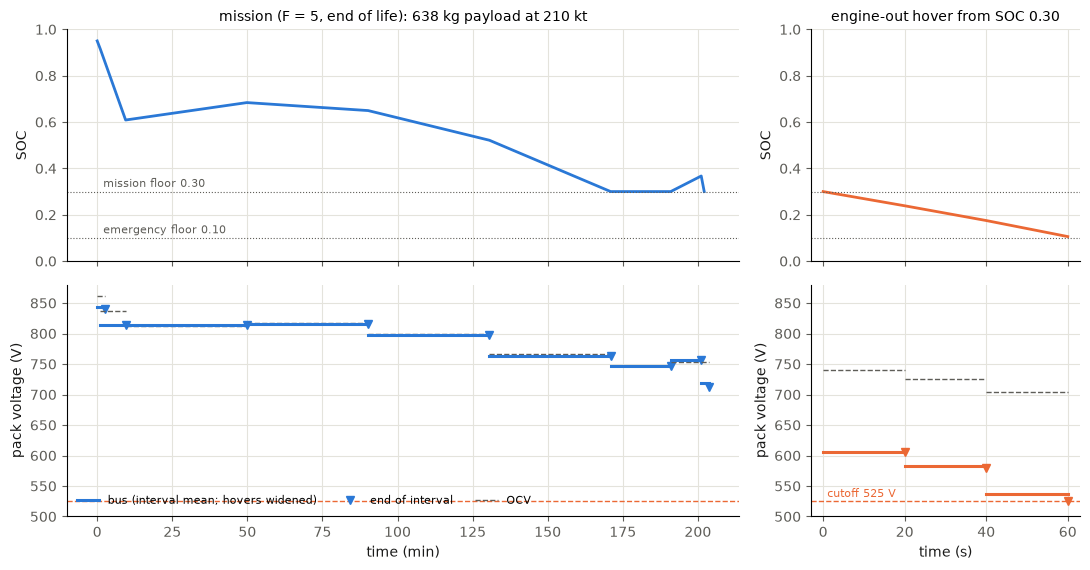

In [7]:
trace = ecm.battery_trace
fig, axes = plt.subplots(2, 2, figsize=(11, 5.8), sharex="col", gridspec_kw=dict(width_ratios=[3, 1.2]))
for column, rows, scale, unit in ((0, trace, 60.0, "min"), (1, ecm.engine_out_trace, 1.0, "s")):
    ax, ax2 = axes[0, column], axes[1, column]
    color = blue if column == 0 else orange
    t = np.array([[r["time_start_s"], r["time_start_s"] + r["duration_s"]] for r in rows]).ravel() / scale
    ax.plot(t, np.array([[r["soc_start"], r["soc_end"]] for r in rows]).ravel(), color=color, lw=2)
    for r in rows:
        x = np.array([r["time_start_s"], r["time_start_s"] + r["duration_s"]]) / scale
        if column == 0 and r["duration_s"] < 120:     # hovers: widen the 60 s bars so they are visible
            x = np.array([x[0], x[0] + 2.5])
        ax2.plot(x, [r["voltage_ocv_V"]] * 2, color=ink_muted, lw=1, ls="--")
        ax2.plot(x, [r["voltage_bus_V"]] * 2, color=color, lw=2.2)
        ax2.plot(x[1], r["voltage_end_V"], "v", color=color, markersize=6)
    ax.axhline(soc_minimum, color=ink_muted, lw=0.8, ls=":")
    ax.axhline(soc_emergency_floor, color=ink_muted, lw=0.8, ls=":")
    ax2.axhline(525.0, color=orange, lw=1, ls="--")
    ax2.set(xlabel=f"time ({unit})", ylabel="pack voltage (V)")
    ax.set(ylabel="SOC", ylim=(0, 1))
axes[0, 0].annotate("mission floor 0.30", xy=(2, 0.32), fontsize=8, color=ink_muted)
axes[0, 0].annotate("emergency floor 0.10", xy=(2, 0.12), fontsize=8, color=ink_muted)
axes[0, 0].set_title(f"mission (F = 5, end of life): {ecm.mass_payload_kg:.0f} kg payload at 210 kt", fontsize=10)
axes[0, 1].set_title("engine-out hover from SOC 0.30", fontsize=10)
axes[1, 1].annotate("cutoff 525 V", xy=(1, 532), fontsize=8, color=orange)
axes[1, 0].plot([], [], color=blue, lw=2.2, label="bus (interval mean; hovers widened)")
axes[1, 0].plot([], [], "v", color=blue, label="end of interval")
axes[1, 0].plot([], [], color=ink_muted, lw=1, ls="--", label="OCV")
axes[1, 0].legend(frameon=False, fontsize=8, loc="lower left", ncol=3)
axes[1, 0].set_ylim(500, 880)
axes[1, 1].set_ylim(500, 880)
fig.tight_layout()
check("bus voltage tracks the OCV curve through the mission (OCV range > 80 V)",
      max(r["voltage_ocv_V"] for r in trace) - min(r["voltage_ocv_V"] for r in trace) > 80)

## 6. Sensitivity: power-density factor, ageing, cell temperature

The payload objective is warm-started along the sweep. At low F the battery
current rating binds, and then the cutoff voltage. At high F the energy
window binds instead: 60 s at about 590 kW between SOC 0.30 and 0.10.

    F  payload kg  battery kg  kWh EOL   cells  battery-related binding
    2          73        1005    148.0   10191  battery discharge_current_A
    3         384         721    106.1    7310  battery discharge_current_A
    5         638         466     68.7    4730  battery end voltage_V
    8         687         422     62.2    4284  soc_after_engine_out_hover
   12         707         411     60.5    4168  soc_after_engine_out_hover
   20         722         404     59.5    4098  soc_after_engine_out_hover
F = 1.5: no closed design (payload would be negative)
PASS  payload rises monotonically with the power-density factor
PASS  power binds at low F (current or voltage), energy at high F
PASS  even at F = 20 the pack cannot recover the 900 kg payload


CasADi - 2026-10-04 08:09:52 WARNING("solver:nlp_g failed: NaN detected for output g, at (row 144, col 0).") [.../casadi/core/oracle_function.cpp:408]


beginning of life: payload 693 kg (end of life 638 kg); 0 C cell: 431 kg
PASS  ageing costs payload
PASS  a cold (0 C) pack costs payload


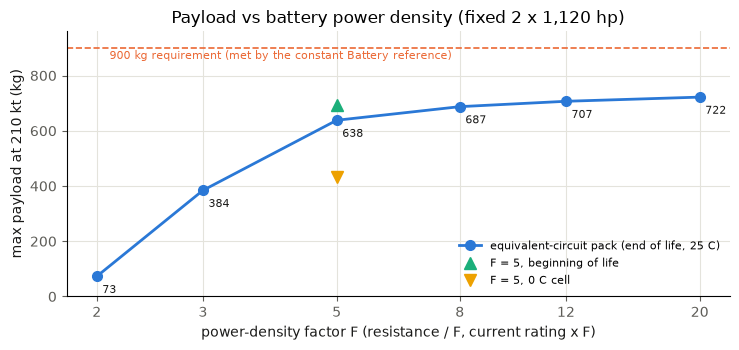

In [8]:
sweep, previous = {}, ecm
for F in (8.0, 12.0, 20.0):
    previous = sweep[F] = solve_halo_sizing(assumptions=replace(assumptions_tier17, factor_power_density_battery=F),
                                            objective="payload", initial=previous)
sweep[5.0], previous = ecm, ecm
for F in (3.0, 2.0):
    previous = sweep[F] = solve_halo_sizing(assumptions=replace(assumptions_tier17, factor_power_density_battery=F),
                                            objective="payload", initial=previous)
try:
    solve_halo_sizing(assumptions=replace(assumptions_tier17, factor_power_density_battery=1.5), objective="payload",
                      initial=sweep[2.0])
    closes_15 = True
except RuntimeError:
    closes_15 = False
factors = sorted(sweep)
print(f"{'F':>5} {'payload kg':>11} {'battery kg':>11} {'kWh EOL':>8} {'cells':>7}  battery-related binding")
for F in factors:
    r = sweep[F]
    binding = [b.split(": ", 1)[-1] for b in r.binding if "battery" in b or "engine_out" in b]
    print(f"{F:>5g} {r.mass_payload_kg:>11.0f} {dict(r.powertrain_masses_kg)['battery']:>11.0f} "
          f"{r.energy_battery_kWh:>8.1f} {210 * r.design.count_parallel_battery:>7.0f}  {', '.join(binding)}")
print("F = 1.5:", "closes" if closes_15 else "no closed design (payload would be negative)")
check("payload rises monotonically with the power-density factor",
      all(sweep[a].mass_payload_kg < sweep[b].mass_payload_kg for a, b in zip(factors, factors[1:])))
check("power binds at low F (current or voltage), energy at high F",
      any("discharge_current_A" in b for b in sweep[2.0].binding)
      and "soc_after_engine_out_hover" in sweep[12.0].binding)
check("even at F = 20 the pack cannot recover the 900 kg payload", sweep[20.0].mass_payload_kg < 900)

bol = solve_halo_sizing(assumptions=replace(assumptions_tier17, factor_capacity_ageing_battery=1.0,
                                            factor_resistance_ageing_battery=1.0), objective="payload",
                        initial=base)   # warm starts matter (IPOPT is local; multistart is Tier 22)
cold = solve_halo_sizing(assumptions=replace(assumptions_tier17, temperature_cell_battery_C=0.0), objective="payload",
                         initial=ecm)
print(f"beginning of life: payload {bol.mass_payload_kg:.0f} kg (end of life {ecm.mass_payload_kg:.0f} kg); "
      f"0 C cell: {cold.mass_payload_kg:.0f} kg")
check("ageing costs payload", bol.mass_payload_kg > ecm.mass_payload_kg)
check("a cold (0 C) pack costs payload", cold.mass_payload_kg < ecm.mass_payload_kg)

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.plot(factors, [sweep[F].mass_payload_kg for F in factors], "o-", color=blue, lw=2, markersize=7,
        label="equivalent-circuit pack (end of life, 25 C)")
ax.axhline(base.mass_payload_kg, color=orange, lw=1.2, ls="--")
ax.annotate("900 kg requirement (met by the constant Battery reference)", xy=(2.1, 860), fontsize=8,
            color=orange)
ax.plot([5.0], [bol.mass_payload_kg], "^", color=aqua, markersize=8, label="F = 5, beginning of life")
ax.plot([5.0], [cold.mass_payload_kg], "v", color=yellow, markersize=8, label="F = 5, 0 C cell")
for F in factors:
    ax.annotate(f"{sweep[F].mass_payload_kg:.0f}", xy=(F, sweep[F].mass_payload_kg), xytext=(4, -12),
                textcoords="offset points", fontsize=8, color=ink)
ax.set(xscale="log", xlabel="power-density factor F (resistance / F, current rating x F)",
       ylabel="max payload at 210 kt (kg)", title="Payload vs battery power density (fixed 2 x 1,120 hp)")
ax.set_xticks(factors, [f"{F:g}" for F in factors])
ax.minorticks_off()
ax.set_ylim(0, 960)
ax.legend(frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()

## 7. Reading the result

- **The discharge curve is now real.** Bus voltage follows the 50G's OCV
  curve, from about 860 V at take-off to 750 V at the 0.30 floor. It sags
  by tens of volts in hover and by up to 25 % in the engine-out reserve,
  where the low-SOC end reaches the 2.5 V-per-cell cutoff. That is the
  minimum-voltage case the machines and inverters must accept (525 V,
  inside their 400 V floor).
- **The engine-out reserve sizes the pack.**
  - Below F of about 5 to 8, it sizes the pack through power: the current
    rating, then the cutoff voltage at low SOC.
  - Above that, it sizes the pack through energy: 60 s at about 590 kW must
    fit in the 0.30 to 0.10 SOC window.
  - Making the cell more power-dense stops paying off near F = 8.
- **The requirement does not close with real cells on the fixed engines.**
  The 50G's 263 Wh/kg becomes 184 Wh/kg in the pack and 147 Wh/kg at end of
  life. The old assumption was 250 Wh/kg with no ageing. Even at F = 20 the
  payload is about 720 kg, against 900 kg required. This is why the
  reference keeps the constant battery for now.
- **What the user needs to decide:**
  - Reduce payload or speed.
  - Redefine the reserve: a wider SOC window, a shorter engine-out hover, or
    a beginning-of-life rating.
  - Accept a different cell or chemistry trade.
- **What remains assumed:** the cell-to-pack ratio, the end-of-life factors,
  the charge rating (1C x F), the 25 C cell temperature, and the use of
  discharge resistance for charging too.

## 8. Summary and unit test suite

In [9]:
failed = [name for name, passed in check_log if not passed]
print(f"{len(check_log) - len(failed)} / {len(check_log)} notebook checks passed")
for name in failed:
    print("  FAIL:", name)

21 / 21 notebook checks passed


In [10]:
import os, unittest

os.chdir(repo_root)
suite = unittest.defaultTestLoader.discover(str(repo_root / "tests"), top_level_dir=str(repo_root / "tests"))
test_result = unittest.TextTestRunner(verbosity=1, stream=sys.stdout).run(suite)
assert test_result.wasSuccessful() and not failed, "Verification failed"

C:\Users\alexa\Documents\Chasing Amber\halo\.venv\Lib\site-packages\casadi\casadi.py:913: FutureWarning: 
casadi: a numpy function was called on a casadi value (issue #2959).
This used legacy casadi 3.7.2 behaviour, where the result type follows
the input:
  - a numeric input (DM)       -> a plain numpy array
  - a symbolic input (SX / MX) -> a casadi value, or an error if the
                                  function has no casadi equivalent

For a shape-correct, type-preserving result, opt in to the
casadi-aware numpy support:

    try:
        ca.GlobalOptions.setNumpyMode(1)
    except AttributeError:
        pass

Or use setNumpyMode(-1) to keep legacy behaviour silently.
Shown once; run python with -W always to see every occurrence.

  _w.warn(_NUMPY_LEGACY_NOTICE, FutureWarning)


.

.

.

.

...

.

.

.

.

----------------------------------------------------------------------
Ran 431 tests in 762.013s

OK
